In [71]:
import sys
sys.path.append("..")
import onep

import pickle as pkl
import numpy as np
import sklearn
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
from scipy.stats import zscore


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

# Setup

In [17]:
ddir = 'C:/Users/ryansenne/Desktop/Dill/'
time_vector = pd.read_csv(ddir + "time.csv").to_numpy().squeeze()

In [18]:
time_vector

array([0.00000000e+00, 9.99218740e-02, 1.99843747e-01, ...,
       3.59618823e+02, 3.59718745e+02, 3.59818667e+02])

# FC Decoding

In [51]:
# load all animals accepted traces and the time vectors:
subdir_fc = "fc_traces_csv"
fc_dir = os.path.join(ddir, subdir_fc)
fc_files = os.listdir(fc_dir)

fc_data = {}
for f in fc_files:
    if f.endswith("accepted_traces.csv"):
        animal_id = f.split("_")[0]
        data = pd.read_csv(os.path.join(fc_dir, f))
        data = data.to_numpy()[:3302, :].squeeze()
        fc_data[animal_id] = data


In [19]:
EVENTS_SEC = np.array([120, 180, 240, 300], dtype=float)

PRE_SEC = 0.0
POST_SEC = 30.0

DOWNSAMPLE_EVERY = 1  # 1 = no downsample, 2 = take every 2nd sample, etc.

# Ridge hyperparameters to tune
ALPHAS = np.logspace(-3, 5, 25)

In [20]:
def extract_event_window(X_tm, t, event_sec, pre_sec, post_sec, downsample_every=1):
    """
    X_tm: (T, m) trace matrix
    t: (T,) time vector in seconds
    Returns:
        X_win: (L, m)
        y_win: (L,) continuous time-from-event (seconds)
        idx: indices into the original time vector
    """
    lo, hi = event_sec - pre_sec, event_sec + post_sec
    idx = np.where((t >= lo) & (t <= hi))[0]
    if idx.size == 0:
        return None, None, None
    if downsample_every > 1:
        idx = idx[::downsample_every]
    X_win = X_tm[idx, :]
    y_win = t[idx] - event_sec
    return X_win, y_win, idx

def leave_one_event_out_decode(X_tm, t, events_sec, pre_sec, post_sec,
                               downsample_every=1, alphas=ALPHAS, n_perm=200, random_state=0):
    """
    Leave-one-event-out CV within a subject.
    Returns a dict with fold metrics + permutation null summaries.
    """
    rng = np.random.default_rng(random_state)

    # Build per-event datasets
    per_event = []
    for e in events_sec:
        Xw, yw, idx = extract_event_window(X_tm, t, e, pre_sec, post_sec, downsample_every)
        if Xw is None:
            continue
        per_event.append((e, Xw, yw))

    if len(per_event) < 2:
        return {"error": "Not enough events with samples in window."}

    results = {"folds": [], "summary": {}, "perm": []}

    # Model: standardize features, ridge regression
    base = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("ridge", Ridge())
    ])

    # Nested tuning on training folds only
    param_grid = {"ridge__alpha": alphas}

    for hold_idx in range(len(per_event)):
        e_test, X_test, y_test = per_event[hold_idx]

        X_train_list, y_train_list = [], []
        for j, (e, Xw, yw) in enumerate(per_event):
            if j == hold_idx:
                continue
            X_train_list.append(Xw)
            y_train_list.append(yw)

        X_train = np.vstack(X_train_list)
        y_train = np.concatenate(y_train_list)

        # Tune alpha on training data (inner CV)
        gscv = GridSearchCV(base, param_grid=param_grid, cv=5, n_jobs=-1)
        gscv.fit(X_train, y_train)

        best_model = gscv.best_estimator_
        y_pred = best_model.predict(X_test)

        fold = {
            "event_sec": float(e_test),
            "best_alpha": float(gscv.best_params_["ridge__alpha"]),
            "mae": float(mean_absolute_error(y_test, y_pred)),
            "r2": float(r2_score(y_test, y_pred)),
            "corr": float(np.corrcoef(y_test, y_pred)[0, 1]) if np.std(y_pred) > 1e-12 else np.nan,
            "n_test": int(len(y_test))
        }
        results["folds"].append(fold)

        # Permutation test: shuffle y_train (break time mapping) and refit; evaluate on same test
        perm_mae = []
        for _ in range(n_perm):
            y_train_shuff = rng.permutation(y_train)
            perm_model = gscv.best_estimator_
            # refit with same alpha to avoid re-running grid each perm (much faster)
            alpha = gscv.best_params_["ridge__alpha"]
            perm_model.set_params(ridge__alpha=alpha)
            perm_model.fit(X_train, y_train_shuff)
            y_perm = perm_model.predict(X_test)
            perm_mae.append(mean_absolute_error(y_test, y_perm))

        results["perm"].append({
            "event_sec": float(e_test),
            "perm_mae_mean": float(np.mean(perm_mae)),
            "perm_mae_std": float(np.std(perm_mae)),
            "perm_mae_p": float((np.sum(np.array(perm_mae) <= fold["mae"]) + 1) / (n_perm + 1)),  # lower MAE is better
        })

    # Summaries across folds
    maes = np.array([f["mae"] for f in results["folds"]], dtype=float)
    r2s = np.array([f["r2"] for f in results["folds"]], dtype=float)
    cors = np.array([f["corr"] for f in results["folds"]], dtype=float)

    results["summary"] = {
        "mae_mean": float(np.mean(maes)),
        "mae_sem": float(np.std(maes) / np.sqrt(len(maes))),
        "r2_mean": float(np.mean(r2s)),
        "corr_mean": float(np.nanmean(cors)),
        "n_folds": int(len(results["folds"]))
    }
    return results


In [ ]:
EVENTS_SEC = np.array([120, 180, 240, 300], dtype=float)

PRE_SEC = 30.0
POST_SEC = 60.0

# If you want fewer samples, you can downsample within the window:
DOWNSAMPLE_EVERY = 1  # 1 = no downsample, 2 = take every 2nd sample, etc.

# Ridge hyperparameters to tune
ALPHAS = np.logspace(-3, 5, 25)

In [ ]:
all_results = {}
for animal_id, X in fc_data.items():
    res = leave_one_event_out_decode(
        X_tm=X,
        t=time_vector[:X.shape[0]],
        events_sec=EVENTS_SEC,
        pre_sec=PRE_SEC,
        post_sec=POST_SEC,
        downsample_every=DOWNSAMPLE_EVERY,
        alphas=ALPHAS,
        n_perm=200,
        random_state=0
    )
    all_results[animal_id] = res

# Convert summaries to a dataframe for easy viewing
rows = []
for animal_id, res in all_results.items():
    if "error" in res:
        rows.append({"animal_id": animal_id, "error": res["error"]})
        continue
    s = res["summary"]
    rows.append({
        "animal_id": animal_id,
        "mae_mean": s["mae_mean"],
        "mae_sem": s["mae_sem"],
        "r2_mean": s["r2_mean"],
        "corr_mean": s["corr_mean"],
        "n_folds": s["n_folds"]
    })

df_summary_fc = pd.DataFrame(rows).sort_values("animal_id")

In [ ]:
# Build a per-fold permutation-results table
perm_rows = []
for animal_id, res in all_results.items():
    if "error" in res:
        continue
    for fold, perm in zip(res["folds"], res["perm"]):
        perm_rows.append({
            "animal_id": animal_id,
            "heldout_event_sec": fold["event_sec"],
            "mae": fold["mae"],
            "perm_mae_mean": perm["perm_mae_mean"],
            "perm_mae_std": perm["perm_mae_std"],
            "perm_p_mae": perm["perm_mae_p"],   # p-value: fraction of perm MAE <= true MAE (lower is better)
            "best_alpha": fold["best_alpha"],
            "r2": fold["r2"],
            "corr": fold["corr"],
            "n_test": fold["n_test"],
        })

df_perm_fc = pd.DataFrame(perm_rows).sort_values(["animal_id", "heldout_event_sec"])

In [ ]:
df_summary_fc.to_csv(ddir + "decoding_summary.csv", index=False)
df_perm_fc.to_csv(ddir + "decoding_per_fold.csv", index=False)

In [ ]:
df_perm_fc

,animal_id,heldout_event_sec,mae,perm_mae_mean,perm_mae_std,perm_p_mae,best_alpha,r2,corr,n_test
0,astroF10,120.0,7.268953,7.662388,0.828912,0.333333,2154.434690,-0.406869,0.785435,301
1,astroF10,180.0,5.379246,7.486773,0.118021,0.004975,21544.346900,0.442687,0.695707,300
2,astroF10,240.0,5.258200,7.519590,0.129585,0.004975,21544.346900,0.462880,0.695207,301
3,astroF10,300.0,5.833835,7.467858,0.085422,0.004975,21544.346900,0.358248,0.726786,299
4,astroF3,120.0,6.188740,7.541434,0.180909,0.004975,1000.000000,0.332161,0.592688,301
5,astroF3,180.0,5.754224,7.532196,0.196928,0.004975,464.158883,0.381827,0.624452,300
6,astroF3,240.0,5.491989,7.519560,0.118375,0.004975,4641.588834,0.424964,0.666956,301
7,astroF3,300.0,6.457239,7.521375,0.144520,0.004975,464.158883,0.297756,0.615583,299
8,astroF5,120.0,7.332512,7.537396,0.271204,0.223881,2154.434690,0.010500,0.545300,301
9,astroF5,180.0,6.446772,7.489878,0.079486,0.004975,21544.346900,0.248160,0.529523,300


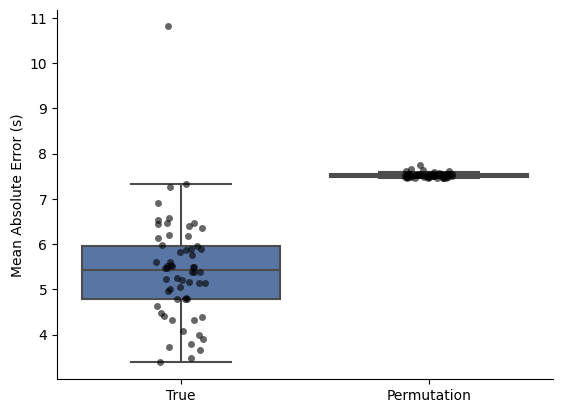

In [ ]:
df_long = pd.melt(
    df_perm_fc,
    id_vars=["animal_id", "heldout_event_sec"],
    value_vars=["mae", "perm_mae_mean"],
    var_name="condition",
    value_name="MAE_sec"
)

df_long["condition"] = df_long["condition"].map({
    "mae": "True",
    "perm_mae_mean": "Permutation"
})

sns.boxplot(data=df_long, x="condition", y="MAE_sec", showfliers=False)
sns.stripplot(data=df_long, x="condition", y="MAE_sec", color="k", alpha=0.6)
plt.ylabel("Mean Absolute Error (s)")
plt.xlabel("")
plt.show()


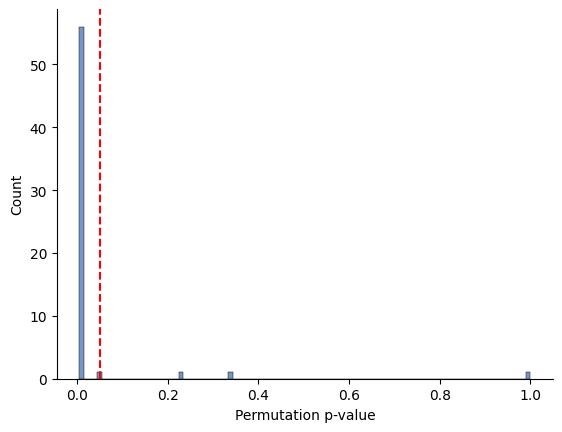

In [ ]:
sns.histplot(df_perm_fc["perm_p_mae"], bins=100)
plt.axvline(0.05, color="r", linestyle="--")
plt.xlabel("Permutation p-value")
plt.ylabel("Count")
plt.show()


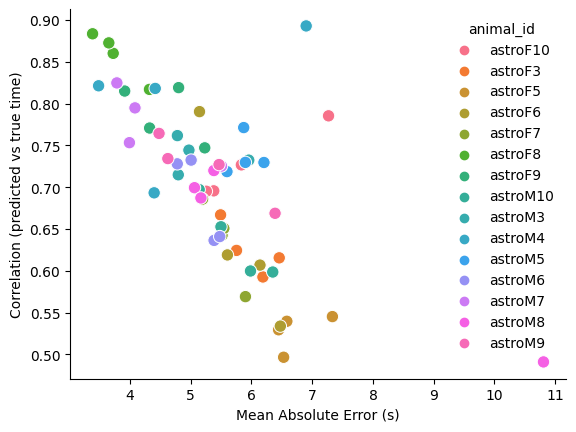

In [ ]:
sns.scatterplot(
    data=df_perm_fc,
    x="mae",
    y="corr",
    hue="animal_id",
    s=80
)
plt.xlabel("Mean Absolute Error (s)")
plt.ylabel("Correlation (predicted vs true time)")
plt.show()


# Cxt A Decoding


In [59]:
def get_animal_events_from_wide(df_event_times, animal_id, suffix="_cxta"):
    """
    df_event_times: wide dataframe, columns like 'astroF10_cxta', values are event times (sec), NaN-padded
    animal_id: e.g. 'astroF10'
    returns: np.array of event times (float), sorted, NaNs dropped
    """
    # candidate column names
    candidates = [
        animal_id,
        f"{animal_id}{suffix}",
        animal_id.replace(suffix, "") + suffix,  # if animal_id already had suffix weirdness
    ]
    col = None
    for c in candidates:
        if c in df_event_times.columns:
            col = c
            break
    if col is None:
        return np.array([], dtype=float)

    events = df_event_times[col].to_numpy(dtype=float)
    events = events[np.isfinite(events)]  # drop NaNs
    events = np.unique(events)            # drop duplicates
    events.sort()
    return events

In [60]:
# load all animals accepted traces and the time vectors:
subdir_a = "cxta_traces_csv"
cxta_dir = os.path.join(ddir, subdir_a)
cxta_files = os.listdir(cxta_dir)

# for cxt a we need to load in the detected event times
cxt_a_event_times = pd.read_csv(os.path.join(cxta_dir, "event_times_cxta.csv"))

cxta_data = {}
for f in cxta_files:
    if f.endswith("accepted_traces.csv"):
        animal_id = f.split("_")[0]
        data = pd.read_csv(os.path.join(cxta_dir, f)).to_numpy()
        data = data[:3302, :]

        # ensure shape is (T, m) not (m, T)
        if data.shape[0] != len(time_vector) and data.shape[1] == len(time_vector):
            data = data.T

        cxta_data[animal_id] = data

all_results_a = {}
for animal_id, X in cxta_data.items():
    events_sec = get_animal_events_from_wide(cxt_a_event_times, animal_id, suffix="_cxta")

    # optional: guardrails
    if len(events_sec) < 2:
        all_results_a[animal_id] = {"error": f"Need >=2 events, found {len(events_sec)}"}
        continue

    # optional: ensure events are within time_vector range (+window)
    t = time_vector[:X.shape[0]]
    events_sec = events_sec[(events_sec >= t.min() + PRE_SEC) & (events_sec <= t.max() - POST_SEC)]
    if len(events_sec) < 2:
        all_results_a[animal_id] = {"error": f"Events out of range after windowing; found {len(events_sec)}"}
        continue

    res = leave_one_event_out_decode(
        X_tm=X,
        t=t,
        events_sec=events_sec,
        pre_sec=PRE_SEC,
        post_sec=POST_SEC,
        downsample_every=DOWNSAMPLE_EVERY,
        alphas=ALPHAS,
        n_perm=200,
        random_state=0
    )
    all_results_a[animal_id] = res

# Convert summaries to a dataframe for easy viewing
rows = []
for animal_id, res in all_results_a.items():
    if "error" in res:
        rows.append({"animal_id": animal_id, "error": res["error"]})
        continue
    s = res["summary"]
    rows.append({
        "animal_id": animal_id,
        "n_events_used": s["n_folds"],  # leave-one-event-out folds == num events used
        "mae_mean": s["mae_mean"],
        "mae_sem": s["mae_sem"],
        "r2_mean": s["r2_mean"],
        "corr_mean": s["corr_mean"],
    })

df_summary_a = pd.DataFrame(rows).sort_values("animal_id")
print(df_summary_a)


   animal_id  n_events_used  mae_mean   mae_sem   r2_mean  corr_mean
0   astroF10              2  5.469347  0.250134  0.413355   0.719806
1    astroF3              3  5.584998  0.198757  0.432765   0.677326
2    astroF5              3  5.591411  0.346835  0.449572   0.719075
3    astroF6              2  7.304423  0.073245  0.063680   0.501282
4    astroF7              2  7.063105  0.322039 -0.146314   0.684802
5    astroF8              2  6.765057  0.170054  0.169830   0.550123
6    astroF9              4  4.685443  0.501861  0.545927   0.835131
7   astroM10              5  5.296304  0.146927  0.472004   0.694864
8    astroM3              3  5.486742  0.923526  0.231328   0.825540
9    astroM4              3  5.949229  0.350828  0.198825   0.711921
10   astroM5              2  5.193529  0.496684  0.514701   0.855040
11   astroM9              2  4.796067  0.539600  0.578352   0.864995


In [63]:
# Build a per-fold permutation-results table
perm_rows = []
for animal_id, res in all_results_a.items():
    if "error" in res:
        continue
    for fold, perm in zip(res["folds"], res["perm"]):
        perm_rows.append({
            "animal_id": animal_id,
            "heldout_event_sec": fold["event_sec"],
            "mae": fold["mae"],
            "perm_mae_mean": perm["perm_mae_mean"],
            "perm_mae_std": perm["perm_mae_std"],
            "perm_p_mae": perm["perm_mae_p"],   # p-value: fraction of perm MAE <= true MAE (lower is better)
            "best_alpha": fold["best_alpha"],
            "r2": fold["r2"],
            "corr": fold["corr"],
            "n_test": fold["n_test"],
        })

df_perm_a = pd.DataFrame(perm_rows).sort_values(["animal_id", "heldout_event_sec"])
df_perm_a

,animal_id,heldout_event_sec,mae,perm_mae_mean,perm_mae_std,perm_p_mae,best_alpha,r2,corr,n_test
0,astroF10,150.889842,5.115604,7.471197,0.253059,0.004975,4641.588834,0.479397,0.811250,300
1,astroF10,224.532263,5.823090,7.501017,0.154069,0.004975,4641.588834,0.347313,0.628362,300
2,astroF3,58.761874,5.128668,7.525114,0.176710,0.004975,2154.434690,0.504776,0.721584,300
3,astroF3,207.445622,5.960108,7.480609,0.191946,0.004975,2154.434690,0.391716,0.655735,300
4,astroF3,278.490075,5.666218,7.578222,0.297832,0.004975,1000.000000,0.401804,0.654661,300
5,astroF5,84.241952,4.746890,7.551298,0.290192,0.004975,2154.434690,0.589753,0.790717,300
6,astroF5,130.305936,6.093762,7.481599,0.124642,0.004975,2154.434690,0.390117,0.747559,300
7,astroF5,169.675154,5.933581,7.515543,0.225645,0.004975,1000.000000,0.368844,0.618948,300
8,astroF6,52.866484,7.408006,7.494953,0.012952,0.004975,100000.000000,0.027531,0.577042,300
9,astroF6,286.783590,7.200839,7.501412,0.102072,0.004975,1000.000000,0.099829,0.425522,300


In [64]:
df_summary_a.to_csv(ddir + "decoding_summary_cxta.csv", index=False)
df_perm_a.to_csv(ddir + "decoding_per_fold_cxta.csv", index=False)

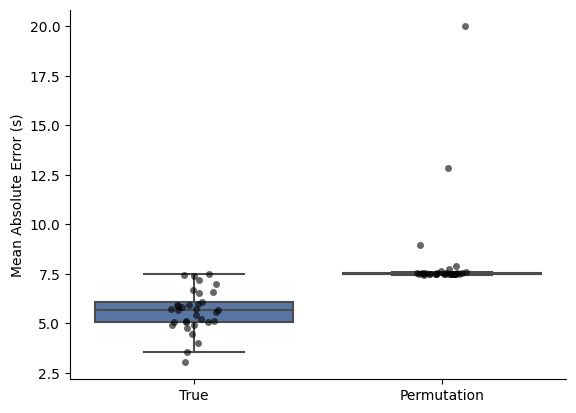

In [65]:
df_long_a = pd.melt(
    df_perm_a,
    id_vars=["animal_id", "heldout_event_sec"],
    value_vars=["mae", "perm_mae_mean"],
    var_name="condition",
    value_name="MAE_sec"
)

df_long_a["condition"] = df_long_a["condition"].map({
    "mae": "True",
    "perm_mae_mean": "Permutation"
})

sns.boxplot(data=df_long_a, x="condition", y="MAE_sec", showfliers=False)
sns.stripplot(data=df_long_a, x="condition", y="MAE_sec", color="k", alpha=0.6)
plt.ylabel("Mean Absolute Error (s)")
plt.xlabel("")
plt.show()

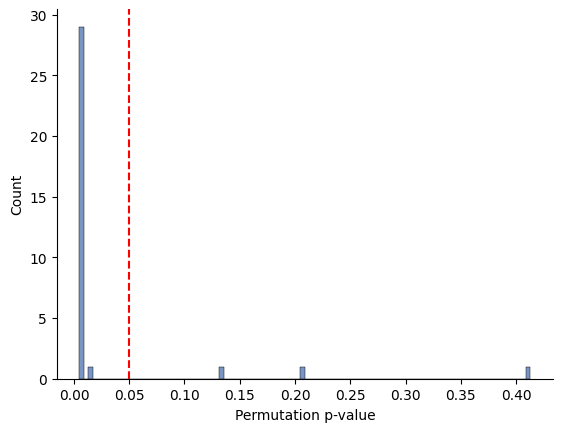

In [116]:
sns.histplot(df_perm_a["perm_p_mae"], bins=100)
plt.axvline(0.05, color="r", linestyle="--")
plt.xlabel("Permutation p-value")
plt.ylabel("Count")
plt.show()

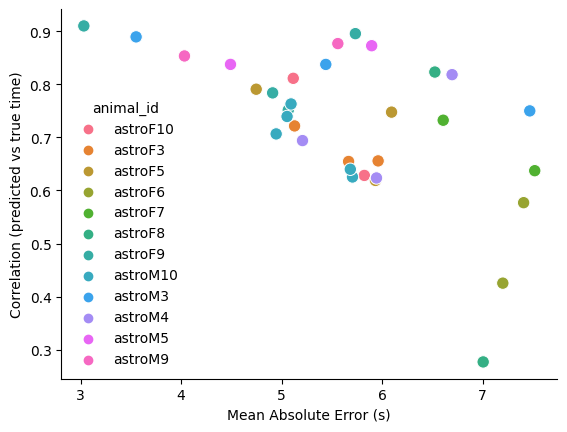

In [117]:
sns.scatterplot(
    data=df_perm_a,
    x="mae",
    y="corr",
    hue="animal_id",
    s=80
)
plt.xlabel("Mean Absolute Error (s)")
plt.ylabel("Correlation (predicted vs true time)")
plt.show()


## Cxt B Decoding

In [84]:
# load all animals accepted traces and the time vectors:
subdir_b = "cxtb_traces_csv"
cxtb_dir = os.path.join(ddir, subdir_b)
cxtb_files = os.listdir(cxtb_dir)

# for cxt a we need to load in the detected event times
cxt_b_event_times = pd.read_csv(os.path.join(cxtb_dir, "event_times_cxtb.csv"))

cxtb_data = {}
for f in cxtb_files:
    if f.endswith("accepted_traces.csv"):
        animal_id = f.split("_")[0]
        data = pd.read_csv(os.path.join(cxtb_dir, f)).to_numpy()
        data = data[:3302, :]

        # ensure shape is (T, m) not (m, T)
        if data.shape[0] != len(time_vector) and data.shape[1] == len(time_vector):
            data = data.T

        cxtb_data[animal_id] = data

all_results_b = {}
for animal_id, X in cxtb_data.items():
    events_sec = get_animal_events_from_wide(cxt_b_event_times, animal_id, suffix="_cxtb")
    # guardrails
    if len(events_sec) < 2:
        all_results_b[animal_id] = {"error": f"Need >=2 events, found {len(events_sec)}"}
        continue

    # optional: ensure events are within time_vector range (+window)
    t = time_vector[:X.shape[0]]
    events_sec = events_sec[(events_sec >= t.min() + PRE_SEC) & (events_sec <= t.max() - POST_SEC)]
    if len(events_sec) < 2:
        all_results_b[animal_id] = {"error": f"Events out of range after windowing; found {len(events_sec)}"}
        continue

    res = leave_one_event_out_decode(
        X_tm=X,
        t=t,
        events_sec=events_sec,
        pre_sec=PRE_SEC,
        post_sec=POST_SEC,
        downsample_every=DOWNSAMPLE_EVERY,
        alphas=ALPHAS,
        n_perm=200,
        random_state=0
    )
    all_results_b[animal_id] = res

# Convert summaries to a dataframe for easy viewing
rows = []
for animal_id, res in all_results_b.items():
    if "error" in res:
        rows.append({"animal_id": animal_id, "error": res["error"]})
        continue
    s = res["summary"]
    rows.append({
        "animal_id": animal_id,
        "n_events_used": s["n_folds"],  # leave-one-event-out folds == num events used
        "mae_mean": s["mae_mean"],
        "mae_sem": s["mae_sem"],
        "r2_mean": s["r2_mean"],
        "corr_mean": s["corr_mean"],
    })

df_summary_b = pd.DataFrame(rows).sort_values("animal_id")
print(df_summary_b)

   animal_id                     error  n_events_used   mae_mean   mae_sem  \
0   astroF10  Need >=2 events, found 1            NaN        NaN       NaN   
1    astroF3                       NaN            2.0   6.295948  0.278148   
2    astroF5  Need >=2 events, found 1            NaN        NaN       NaN   
3    astroF6  Need >=2 events, found 1            NaN        NaN       NaN   
4    astroF7                       NaN            2.0   7.484156  0.000582   
5    astroF8                       NaN            3.0   5.199226  0.397284   
6    astroF9                       NaN            4.0   7.614978  1.842705   
7   astroM10                       NaN            4.0   5.488343  0.277786   
8    astroM6                       NaN            2.0   5.573377  0.361357   
9    astroM7                       NaN            3.0  10.093649  1.677058   
10   astroM8                       NaN            3.0   7.233662  0.525554   

     r2_mean  corr_mean  
0        NaN        NaN  
1   0.26422

In [85]:
# Build a per-fold permutation-results table
perm_rows = []
for animal_id, res in all_results_b.items():
    if "error" in res:
        continue
    for fold, perm in zip(res["folds"], res["perm"]):
        perm_rows.append({
            "animal_id": animal_id,
            "heldout_event_sec": fold["event_sec"],
            "mae": fold["mae"],
            "perm_mae_mean": perm["perm_mae_mean"],
            "perm_mae_std": perm["perm_mae_std"],
            "perm_p_mae": perm["perm_mae_p"],   # p-value: fraction of perm MAE <= true MAE (lower is better)
            "best_alpha": fold["best_alpha"],
            "r2": fold["r2"],
            "corr": fold["corr"],
            "n_test": fold["n_test"],
        })

df_perm_b = pd.DataFrame(perm_rows).sort_values(["animal_id", "heldout_event_sec"])
df_perm_b

,animal_id,heldout_event_sec,mae,perm_mae_mean,perm_mae_std,perm_p_mae,best_alpha,r2,corr,n_test
0,astroF3,87.839140,5.902586,7.626795,0.599865,0.004975,464.158883,0.307794,0.561342,300
1,astroF3,162.580701,6.689309,7.555205,0.424811,0.029851,215.443469,0.220664,0.612312,300
2,astroF7,147.792264,7.484979,7.494153,0.001290,0.004975,100000.000000,0.002801,0.236649,300
3,astroF7,288.382340,7.483334,7.494222,0.002421,0.004975,100000.000000,0.003677,0.454709,300
4,astroF8,62.658827,5.974628,7.804696,1.046089,0.034826,464.158883,0.249546,0.849850,300
5,astroF8,165.878123,5.320758,7.501420,0.166467,0.004975,10000.000000,0.521452,0.870658,300
6,astroF8,256.807028,4.302291,7.489120,0.196723,0.004975,10000.000000,0.663370,0.854952,300
7,astroF9,91.736093,5.671765,17.293527,4.598044,0.004975,10.000000,0.287654,0.789815,300
8,astroF9,134.902342,4.676863,11.489451,2.587041,0.004975,2.154435,0.543104,0.834658,300
9,astroF9,224.432341,13.929058,7.509331,1.017975,1.000000,4641.588834,-2.916740,-0.675952,300


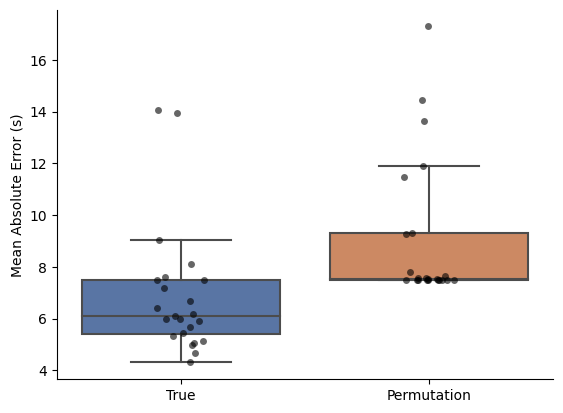

In [88]:
df_long_b = pd.melt(
    df_perm_b,
    id_vars=["animal_id", "heldout_event_sec"],
    value_vars=["mae", "perm_mae_mean"],
    var_name="condition",
    value_name="MAE_sec"
)

df_long_b["condition"] = df_long_b["condition"].map({
    "mae": "True",
    "perm_mae_mean": "Permutation"
})

sns.boxplot(data=df_long_b, x="condition", y="MAE_sec", showfliers=False)
sns.stripplot(data=df_long_b, x="condition", y="MAE_sec", color="k", alpha=0.6)
plt.ylabel("Mean Absolute Error (s)")
plt.xlabel("")
plt.show()

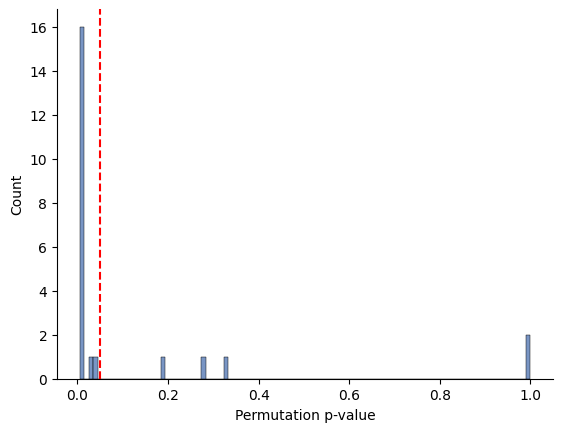

In [91]:
sns.histplot(df_perm_b["perm_p_mae"], bins=100)
plt.axvline(0.05, color="r", linestyle="--")
plt.xlabel("Permutation p-value")
plt.ylabel("Count")
plt.show()

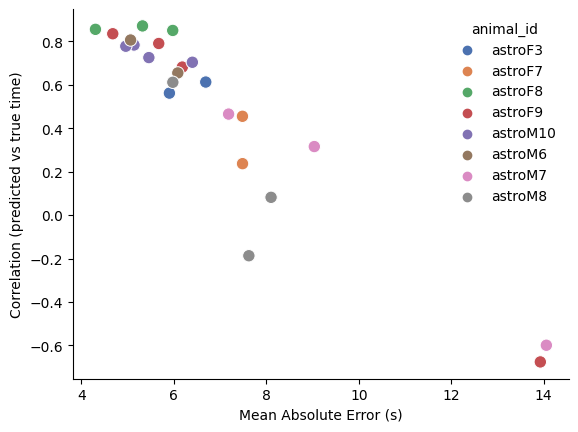

In [89]:
sns.scatterplot(
    data=df_perm_b,
    x="mae",
    y="corr",
    hue="animal_id",
    s=80
)
plt.xlabel("Mean Absolute Error (s)")
plt.ylabel("Correlation (predicted vs true time)")
plt.show()


In [86]:
df_perm_b.to_csv(ddir + "decoding_per_fold_cxtb.csv", index=False)
df_summary_b.to_csv(ddir + "decoding_summary_cxtb.csv", index=False)

# Cross-Condition Decoding (FC-Recall)

In [111]:
# Collections
FC_COLLECTION_PATH    = r"C:\Users\ryansenne\Desktop\Dill\collection_fc_allmice.pkl"
CXT_A_COLLECTION_PATH = r"C:\Users\ryansenne\Desktop\Dill\collection_cxta_allmice.pkl"
CXT_B_COLLECTION_PATH = r"C:\Users\ryansenne\Desktop\Dill\collection_cxtb_allmice.pkl"


def load_collections():
    """Load FC, CxtA, and CxtB collections."""
    with open(FC_COLLECTION_PATH, "rb") as f:
        collection_fc = pickle.load(f)
    with open(CXT_A_COLLECTION_PATH, "rb") as f:
        collection_cxta = pickle.load(f)
    with open(CXT_B_COLLECTION_PATH, "rb") as f:
        collection_cxtb = pickle.load(f)
    return collection_fc, collection_cxta, collection_cxtb

def make_event_samples(X_tm, t, events_sec, pre_sec, post_sec, downsample_every=1):
    """
    Reuses extract_event_window(). Stacks windows across events into a single dataset.
    Returns:
      X: (N, m)
      y: (N,)
      g: (N,) event index for each sample
    """
    X_list, y_list, g_list = [], [], []
    for ei, e in enumerate(events_sec):
        Xw, yw, _ = extract_event_window(
            X_tm=X_tm, t=t, event_sec=float(e),
            pre_sec=pre_sec, post_sec=post_sec,
            downsample_every=downsample_every
        )
        if Xw is None:
            continue
        X_list.append(Xw)
        y_list.append(yw)
        g_list.append(np.full(len(yw), ei, dtype=int))

    if len(X_list) == 0:
        return None, None, None

    return np.vstack(X_list), np.concatenate(y_list), np.concatenate(g_list)

def get_overlap_traces(collection_fc, collection_recall, animal, reg_key, N_SAMPLES=3303):
    """
    Returns:
      X_fc: (T, m) population matrix for FC using overlapping cells
      t_fc: (T,)
      X_rec: (T, m) population matrix for Recall using overlapping cells
      t_rec: (T,)
    or None if cannot build.
    """
    # registration table: columns 0=FC idx, 1=recall idx
    reg = pd.DataFrame(collection_fc.animals[animal].registration_tables[reg_key])

    rejected_fc = pd.Series(collection_fc.animals[animal].rejected_inds)
    rejected_rec = pd.Series(collection_recall.animals[animal].rejected_inds)

    reg_fc_ok = reg[~reg[0].isin(rejected_fc)]
    reg_both_ok = reg_fc_ok[~reg_fc_ok[1].isin(rejected_rec)]

    both = reg_both_ok.loc[(reg_both_ok[0] != -1) & (reg_both_ok[1] != -1)]
    if both.shape[0] == 0:
        return None

    # traces are (n_cells, T)
    fc_traces = np.array(collection_fc.animals[animal].get_traces())
    rec_traces = np.array(collection_recall.animals[animal].get_traces())

    n_fc, T_fc = fc_traces.shape
    n_rec, T_rec = rec_traces.shape

    valid = (both[0] < n_fc) & (both[1] < n_rec)
    both = both.loc[valid]
    if both.shape[0] == 0:
        return None

    fc_idx = both[0].astype(int).to_numpy()
    rec_idx = both[1].astype(int).to_numpy()

    # subset to overlapping cells, truncate time
    fc_active = fc_traces[fc_idx, :N_SAMPLES]
    rec_active = rec_traces[rec_idx, :N_SAMPLES]

    # z-score each cell across time
    fc_dfz = zscore(fc_active, axis=1, nan_policy="omit")
    rec_dfz = zscore(rec_active, axis=1, nan_policy="omit")

    # make (T, m) matrices for the decoder
    X_fc = fc_dfz.T
    X_rec = rec_dfz.T

    # timestamps
    t_fc = collection_fc.animals[animal].Timestamps[:N_SAMPLES].to_numpy().squeeze()
    t_rec = collection_recall.animals[animal].Timestamps[:N_SAMPLES].to_numpy().squeeze()

    return X_fc, t_fc, X_rec, t_rec

def decode_train_fc_test_recall(
    X_fc, t_fc, fc_events_sec,
    X_rec, t_rec, recall_events_sec,
    pre_sec=0.0, post_sec=30.0,
    downsample_every=1,
    alphas=ALPHAS,
    n_perm=200,
    random_state=0
):
    rng = np.random.default_rng(random_state)

    # build training set from FC
    Xtr, ytr, gtr = make_event_samples(X_fc, t_fc, np.array(fc_events_sec, dtype=float),
                                       pre_sec, post_sec, downsample_every)
    if Xtr is None or len(ytr) < 10:
        return {"error": "No FC samples in event windows."}

    # build test set from Recall
    Xte, yte, gte = make_event_samples(X_rec, t_rec, np.array(recall_events_sec, dtype=float),
                                       pre_sec, post_sec, downsample_every)
    if Xte is None or len(yte) < 10:
        return {"error": "No Recall samples in event windows."}

    # model
    base = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge())
    ])
    gscv = GridSearchCV(base, {"ridge__alpha": alphas}, cv=5, n_jobs=-1)
    gscv.fit(Xtr, ytr)
    model = gscv.best_estimator_

    yhat = model.predict(Xte)

    out = {
        "best_alpha": float(gscv.best_params_["ridge__alpha"]),
        "mae": float(mean_absolute_error(yte, yhat)),
        "r2": float(r2_score(yte, yhat)),
        "corr": float(np.corrcoef(yte, yhat)[0, 1]) if np.std(yhat) > 1e-12 else np.nan,
        "n_train": int(len(ytr)),
        "n_test": int(len(yte)),
        "n_recall_events": int(len(np.unique(gte))),
    }

    # permutation test: shuffle y_train, refit (same alpha), evaluate on same test
    alpha = out["best_alpha"]
    perm_mae = []
    perm_corr = []
    for _ in range(n_perm):
        ytr_shuff = rng.permutation(ytr)
        perm_model = Pipeline([
            ("scaler", StandardScaler()),
            ("ridge", Ridge(alpha=alpha))
        ])
        perm_model.fit(Xtr, ytr_shuff)
        yperm = perm_model.predict(Xte)
        perm_mae.append(mean_absolute_error(yte, yperm))
        if np.std(yperm) > 1e-12:
            perm_corr.append(np.corrcoef(yte, yperm)[0, 1])
        else:
            perm_corr.append(np.nan)

    perm_mae = np.array(perm_mae, dtype=float)
    perm_corr = np.array(perm_corr, dtype=float)

    out["perm_mae_mean"] = float(np.mean(perm_mae))
    out["perm_mae_std"]  = float(np.std(perm_mae))
    out["perm_p_mae"]    = float((np.sum(perm_mae <= out["mae"]) + 1) / (n_perm + 1))  # lower MAE is better

    # optional: correlation null too (higher corr is better)
    out["perm_corr_mean"] = float(np.nanmean(perm_corr))
    out["perm_corr_std"]  = float(np.nanstd(perm_corr))
    out["perm_p_corr"]    = float((np.sum(perm_corr >= out["corr"]) + 1) / (n_perm + 1)) if np.isfinite(out["corr"]) else np.nan

    return out

def load_recall_events(csv_path, suffix):
    """
    wide CSV: columns like astroF3_cxta, NaN padded
    returns dict animal -> np.array(event_times_sec)
    """
    df = pd.read_csv(csv_path)
    out = {}
    for col in df.columns:
        animal = col.replace(suffix, "")
        ev = df[col].to_numpy(dtype=float)
        ev = ev[np.isfinite(ev)]
        ev = np.unique(ev)
        ev.sort()
        out[animal] = ev
    return out


In [112]:
FC_EVENTS = np.array([120, 180, 240, 300], dtype=float)

def run_fc_to_context_from_df(
    animal,
    collection_fc,
    collection_ctx,          # collection_cxta or collection_cxtb
    ctx_event_times_df,      # wide DF for this context
    ctx_suffix,              # "_cxta" or "_cxtb"
    reg_key,                 # "FC-A" or "FC-B"
    context_label,           # "CxtA" or "CxtB"
    pre_sec=0.0,
    post_sec=15.0,
    downsample_every=1,
    alphas=ALPHAS,
    n_perm=200,
    random_state=0,
    N_SAMPLES=3303,
):
    # events for this animal
    recall_events_sec = get_animal_events_from_wide(
        ctx_event_times_df, animal, suffix=ctx_suffix
    )
    if recall_events_sec is None or len(recall_events_sec) == 0:
        return {"animal": animal, "context": context_label, "error": f"No {context_label} recall events"}

    # overlapping registered cells
    out = get_overlap_traces(
        collection_fc=collection_fc,
        collection_recall=collection_ctx,
        animal=animal,
        reg_key=reg_key,
        N_SAMPLES=N_SAMPLES
    )
    if out is None:
        return {"animal": animal, "context": context_label, "error": "No overlapping registered cells"}

    X_fc, t_fc, X_rec, t_rec = out

    # filter events to be fully inside [pre, post] window
    recall_events_sec = recall_events_sec[
        (recall_events_sec >= t_rec.min() + pre_sec) &
        (recall_events_sec <= t_rec.max() - post_sec)
    ]
    if len(recall_events_sec) == 0:
        return {"animal": animal, "context": context_label, "error": f"{context_label} events out of range after windowing"}

    # decode
    res = decode_train_fc_test_recall(
        X_fc=X_fc, t_fc=t_fc, fc_events_sec=FC_EVENTS,
        X_rec=X_rec, t_rec=t_rec, recall_events_sec=recall_events_sec,
        pre_sec=pre_sec, post_sec=post_sec,
        downsample_every=downsample_every,
        alphas=alphas,
        n_perm=n_perm,
        random_state=random_state
    )

    res.update({
        "animal": animal,
        "context": context_label,
        "n_cells": int(X_fc.shape[1]),
        "n_recall_events": int(len(recall_events_sec)),
    })
    return res

In [113]:
def animals_in_event_df(event_df, suffix):
    return set([c.replace(suffix, "") for c in event_df.columns])

collection_fc, collection_cxta, collection_cxtb = load_collections()

fc_animals   = set(collection_fc.animals.keys())
cxta_animals = set(collection_cxta.animals.keys())
cxtb_animals = set(collection_cxtb.animals.keys())

A_event_animals = animals_in_event_df(cxt_a_event_times, "_cxta")
B_event_animals = animals_in_event_df(cxt_b_event_times, "_cxtb")

ALL_MICE_A = sorted(fc_animals & cxta_animals & A_event_animals)
ALL_MICE_B = sorted(fc_animals & cxtb_animals & B_event_animals)

print("N mice FC∩CxtA∩events:", len(ALL_MICE_A))
print("N mice FC∩CxtB∩events:", len(ALL_MICE_B))


N mice FC∩CxtA∩events: 12
N mice FC∩CxtB∩events: 11


In [118]:
PRE_SEC = 0.0
POST_SEC = 30.0
DOWNSAMPLE_EVERY = 2
N_SAMPLES = 3303

results = []

# FC -> B
for animal in ALL_MICE_A:
    if "FC-A" not in collection_fc.animals[animal].registration_tables:
        continue

    r = run_fc_to_context_from_df(
        animal=animal,
        collection_fc=collection_fc,
        collection_ctx=collection_cxta,
        ctx_event_times_df=cxt_a_event_times,
        ctx_suffix="_cxta",
        reg_key="FC-A",
        context_label="CxtA",
        pre_sec=PRE_SEC,
        post_sec=POST_SEC,
        downsample_every=DOWNSAMPLE_EVERY,
        alphas=ALPHAS,
        n_perm=200,
        random_state=0,
        N_SAMPLES=N_SAMPLES
    )
    results.append(r)

# FC -> B
for animal in ALL_MICE_B:
    if "FC-B" not in collection_fc.animals[animal].registration_tables:
        continue

    r = run_fc_to_context_from_df(
        animal=animal,
        collection_fc=collection_fc,
        collection_ctx=collection_cxtb,
        ctx_event_times_df=cxt_b_event_times,
        ctx_suffix="_cxtb",
        reg_key="FC-B",
        context_label="CxtB",
        pre_sec=PRE_SEC,
        post_sec=POST_SEC,
        downsample_every=DOWNSAMPLE_EVERY,
        alphas=ALPHAS,
        n_perm=200,
        random_state=0,
        N_SAMPLES=N_SAMPLES
    )
    results.append(r)

df_fc_to_ctx = pd.DataFrame(results).sort_values(["context", "animal"])
print(df_fc_to_ctx)

df_fc_to_ctx.to_csv(ddir + "decoding_fc_to_context.csv", index=False)

      best_alpha       mae        r2      corr  n_train  n_test  \
0      46.415888  6.699286  0.165328  0.523986    602.0   300.0   
1    1000.000000  6.715330  0.196383  0.531954    602.0   450.0   
2     464.158883  7.048068  0.128915  0.436874    602.0   450.0   
3    1000.000000  7.648296 -0.077641  0.053809    602.0   300.0   
4      46.415888  6.789514  0.153546  0.397377    602.0   300.0   
5     464.158883  6.253022  0.242110  0.559199    602.0   300.0   
6     464.158883  6.754472  0.132178  0.385993    602.0   600.0   
7    1000.000000  6.752662  0.212130  0.528497    602.0   750.0   
8    2154.434690  5.294700  0.447483  0.817638    602.0   450.0   
9    1000.000000  5.277909  0.396389  0.691602    602.0   450.0   
10  10000.000000  4.459345  0.535918  0.814380    602.0   300.0   
11    215.443469  5.768361  0.398654  0.792447    602.0   300.0   
12   1000.000000  6.749908  0.173470  0.681324    602.0   150.0   
13    464.158883  6.906746  0.111419  0.370305    602.0   300.

## Build Figures